# 淘宝双十一销售数据分析

## 项目背景
基于 2022 年双十一期间淘宝真实销售数据（和鲸社区获取），分析各大美妆品牌的销售表现，挖掘双十一大促的销售规律。

## 数据说明
- 数据源：双十一销售数据.csv（含价格、销量、评论数、店铺、更新时间等字段）
- 工具：Python + pandas + matplotlib/seaborn

## 分析流程
1. 数据读取与探查（字段类型、规模、分布）
2. 数据清洗（时间格式转换、缺失值/重复值处理、类型修正）
3. 特征构建（销售额 = 价格 × 销量）
4. 业务分析（品牌对比、品类分析、节前节后对比、价格档分析、折扣分析）
5. 可视化输出（柱状图、折线图、组合图）


In [1]:
# ===== 导入库 =====
# pandas：数据分析核心库（DataFrame/Series）
# numpy：数值计算库
import pandas as pd
import numpy as np

In [2]:
# ===== 读取数据 =====
# 读取淘宝双十一销售数据 CSV（注意：原代码为绝对路径，换环境需修改）
# head(10)：预览前 10 行，确认数据结构
taobao_data = pd.read_csv('D:\浏览器杂项\双十一销售数据.csv')
taobao_data.head(10)

,update_time,id,title,price,sale_count,comment_count,店名
0,2022/11/14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719.0,2704.0,自然堂
1,2022/11/14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122.0,1492.0,自然堂
2,2022/11/14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668.0,589.0,自然堂
3,2022/11/14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805.0,4287.0,自然堂
4,2022/11/14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196.0,618.0,自然堂
5,2022/11/14,A18178129035,自然堂 雪域纯粹滋润洗颜霜 110g 补水保湿 洗面奶女 深层清洁,88.0,42858.0,8426.0,自然堂
6,2022/11/14,A18178206572,CHANDO/自然堂雪润皙白晶采霜（滋润型）50g 滋润修护面霜 正品,139.0,3027.0,304.0,自然堂
7,2022/11/14,A18190290933,自然堂 活泉深层净化控油凝露60g 控油补水保湿滋润 活泉精华正品,86.0,6925.0,740.0,自然堂
8,2022/11/14,A18250630014,CHANDO/自然堂 凝时鲜颜肌活修护精华液35ml 淡化细纹护肤精华,216.0,4649.0,630.0,自然堂
9,2022/11/14,A18422797881,CHANDO/自然堂活泉保湿精华套装 保湿补水滋润控油面部护理套装,258.0,2293.0,43.0,自然堂


In [3]:
# ===== 数据探查 =====
# dtypes：各列数据类型；size：总元素个数；columns：列名列表；describe()：数值列统计摘要（均值/最值/分位数）
print('-------------------------该数据集的大致情况-------------------------')
print('该数据的各列数据类型:\n',taobao_data.dtypes)
print(' ')
print('该数据的大小:\n',taobao_data.size)
print(' ')
print('该数据的数据列标签:\n',taobao_data.columns)
print(' ')
print('数据大概情况:\n',taobao_data.describe())

-------------------------该数据集的大致情况-------------------------
该数据的各列数据类型:
 update_time          str
id                   str
title                str
price            float64
sale_count       float64
comment_count    float64
店名                   str
dtype: object
 
该数据的大小:
 193186
 
该数据的数据列标签:
 Index(['update_time', 'id', 'title', 'price', 'sale_count', 'comment_count',
       '店名'],
      dtype='str')
 
数据大概情况:
              price    sale_count  comment_count
count  27598.00000  2.524400e+04   25244.000000
mean     362.83060  1.230178e+04    1121.142529
std      614.17332  5.233693e+04    5271.059943
min        1.00000  0.000000e+00       0.000000
25%       99.00000  2.790000e+02      21.000000
50%      205.00000  1.445000e+03     153.000000
75%      390.00000  6.354500e+03     669.000000
max    11100.00000  1.923160e+06  202930.000000


In [4]:
# ===== 时间格式转换 =====
# 将 update_time 列从字符串转为 datetime 类型，便于后续按日期筛选和排序
# 转换后输出列的类型确认结果
taobao_data['update_time'] = pd.to_datetime(taobao_data['update_time'])
print('执行代码:taobao_data["update_time"] = pd.to_datetime(taobao_data["update_time"])')
print('执行完成!,日期已经转换!')
print('结果如下:\n')
print('taobao_data["update_time"].dtype')
print(taobao_data['update_time'].dtypes)

执行代码:taobao_data["update_time"] = pd.to_datetime(taobao_data["update_time"])
执行完成!,日期已经转换!
结果如下:

taobao_data["update_time"].dtype
datetime64[us]


In [5]:
# ===== 缺失值与重复值检测 =====
# isnull().sum()：统计每列缺失值数量
# duplicated().sum()：统计完全重复的行数
print('-------------------------缺失值和重复值检测-------------------------')
print('缺失值检测结果:\n',taobao_data.isnull().sum())
print(' ')
print('重复值检测结果:\n',taobao_data.duplicated().sum())
print(' ')
print('目前数据表的长度:\n',len(taobao_data))

-------------------------缺失值和重复值检测-------------------------
缺失值检测结果:
 update_time         0
id                  0
title               0
price               0
sale_count       2354
comment_count    2354
店名                  0
dtype: int64
 
重复值检测结果:
 86
 
目前数据表的长度:
 27598


In [6]:
# 查看 sale_count（销量）或 comment_count（评论数）存在缺失的行，确认缺失情况
taobao_data[(taobao_data[['sale_count','comment_count']].isnull().any(axis=1))]

,update_time,id,title,price,sale_count,comment_count,店名
2011,2022-11-14,A527960599636,Shu uemura植村秀新无色限唇膏 口红 长效保湿滋润 显色持久 正品,215.0,NaN,NaN,植村秀
2012,2022-11-14,A528013549083,Shu uemura植村秀晶萃溢彩肌底液30ml 面部精华,590.0,NaN,NaN,植村秀
2013,2022-11-14,A528030330786,Shu uemura 植村秀无色限柔雾唇膏 哑光口红 保湿持久 高饱和显色,215.0,NaN,NaN,植村秀
2014,2022-11-14,A528091449317,shu uemura植村秀无色限唇颊缤纷霜 腮红 口红两用 唇彩 正品,220.0,NaN,NaN,植村秀
2015,2022-11-14,A528191935022,Shu uemura植村秀韵眉膏 染眉膏 多维度丰眉刷头,280.0,NaN,NaN,植村秀
...,...,...,...,...,...,...,...
27593,2022-11-05,A535642405757,SK-II【11-11】全新大眼眼霜skii放大双眼眼部修护精华紧致,590.0,NaN,NaN,SKII
27594,2022-11-05,A535911851408,SK-II 11-11预售skii大眼眼霜sk2眼部修护精华霜淡化黑眼圈,590.0,NaN,NaN,SKII
27595,2022-11-05,A537027211850,SK-II 11-11预售skii前男友护肤面膜sk2精华面膜贴密集修护,1740.0,NaN,NaN,SKII
27596,2022-11-05,A538212160126,SK-II 11-11预售skiisk2神仙水护肤精华油面部套装滋润补水密集修,1190.0,NaN,NaN,SKII


In [7]:
# ===== 数据清洗 =====
# dropna(inplace=True)：删除含缺失值的行
# drop_duplicates(inplace=True)：删除完全重复的行
# 清洗后再次检测，确认数据质量
taobao_data.dropna(inplace=True)
taobao_data.drop_duplicates(inplace=True)
print('缺失值和重复值正在处理中......')
print('再次检测重复值和缺失值')
print('缺失值检测结果:\n',taobao_data.isnull().sum())
print(' ')
print('重复值检测结果:\n',taobao_data.duplicated().sum())
print('目前数据表的长度:\n',len(taobao_data))

缺失值和重复值正在处理中......
再次检测重复值和缺失值
缺失值检测结果:
 update_time      0
id               0
title            0
price            0
sale_count       0
comment_count    0
店名               0
dtype: int64
 
重复值检测结果:
 0
目前数据表的长度:
 25162


In [8]:
# ===== 字段类型修正 =====
# 将销量列从浮点型转为整型（销量应为整数），便于后续聚合计算
taobao_data['sale_count'] = taobao_data['sale_count'].astype('int')
print('执行代码:taobao_data["sale_count"].astype("int")')
print('执行完成!,日期已经转换!')
print('结果如下:\n')
print(taobao_data['sale_count'].dtypes)

执行代码:taobao_data["sale_count"].astype("int")
执行完成!,日期已经转换!
结果如下:

int64


In [9]:
# ===== 特征构建 =====
# 新增'销售额'列 = 单价 × 销量，作为后续分析的核心业务指标
taobao_data['销售额'] = taobao_data['price'] * taobao_data['sale_count']

In [10]:
# ===== 销量 Top10 =====
# 按[店名, 商品名]分组，汇总销量后取销量最高的 10 条
# 用于查看哪些店铺/商品最畅销
taobao_data_Best_selling = taobao_data.groupby(['店名','title'])['sale_count'].sum().reset_index().nlargest(10,'sale_count')
taobao_data_Best_selling

,店名,title,sale_count
1115,妮维雅,德国妮维雅男士洗面奶控油祛痘印保湿去黑头去油清洁面乳液护肤品,16721122
2912,美宝莲,美宝莲眼唇卸妆液 脸部眼部及唇部卸妆油卸妆水温和清爽深层清洁,4811603
3265,蜜丝佛陀,蜜丝佛陀水漾触感粉底霜液膏 遮瑕控油保湿强 彩妆专柜正品,4140140
2334,相宜本草,【双11来啦】相宜本草去死皮膏洁净面部全身温和去角质补水化妆品,3521813
2900,美宝莲,美宝莲好气色轻唇膏 持久滋润保湿补水口红不易褪色不干唇彩正品,3404653
1721,悦诗风吟,innisfree悦诗风吟绿茶保湿洁面膏洗面奶 深层清洁补水洁面乳男女,3377354
3279,蜜丝佛陀,蜜丝佛陀透滑粉饼 干湿两用遮瑕控油防晒定妆 彩妆专柜正品,3340513
1546,悦诗风吟,innisfree/悦诗风吟控油矿物质散粉5g 蜜粉饼粉底定妆持久 彩妆,3334463
1660,悦诗风吟,innisfree/悦诗风吟绿茶水乳套装 补水保湿控油护肤品韩国化妆品,2908821
3019,自然堂,CHANDO/自然堂水润保湿面部护理套装 洗面奶爽肤水乳液面霜补水女,2637416


In [11]:
# ===== 可视化配置 =====
# 导入 matplotlib（绘图）和 seaborn（美化）
# 设置中文字体 SimHei，防止图表中文乱码
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']

In [12]:
# 从 Top10 中分别筛选出妮维雅、自然堂两家店的记录
# concat：纵向拼接两个 DataFrame，用于对比展示
taobao_data_Best_selling_nyw = taobao_data_Best_selling.query('店名 == "妮维雅"')
taobao_data_Best_selling_zrt = taobao_data_Best_selling.query('店名 == "自然堂"')
taobao_data_Best_nyw_zrt = pd.concat([taobao_data_Best_selling_nyw,taobao_data_Best_selling_zrt])
taobao_data_Best_nyw_zrt

,店名,title,sale_count
1115,妮维雅,德国妮维雅男士洗面奶控油祛痘印保湿去黑头去油清洁面乳液护肤品,16721122
3019,自然堂,CHANDO/自然堂水润保湿面部护理套装 洗面奶爽肤水乳液面霜补水女,2637416


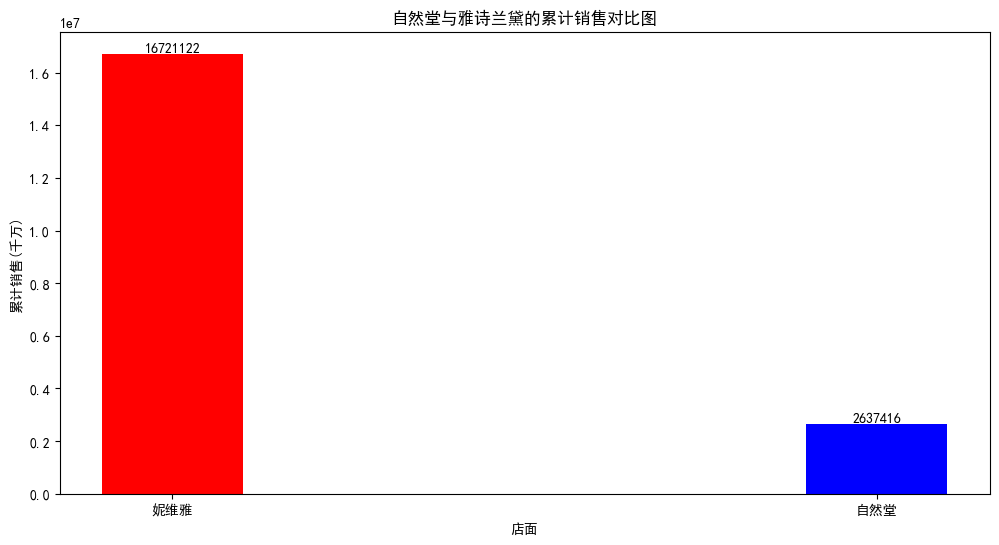

In [13]:
# ===== 品牌销量对比柱状图 =====
# 用柱状图对比妮维雅与自然堂的累计销量
# 循环为每根柱子顶部添加数值标签，便于读数
plt.figure(figsize=(12,6))
bars = plt.bar(taobao_data_Best_nyw_zrt['店名'],taobao_data_Best_nyw_zrt['sale_count'],color=['r','b'],width = 0.2)
for bar_1 in bars:
    height = bar_1.get_height()
    plt.text(bar_1.get_x() + bar_1.get_width()/2,height + 100,f"{height}",ha='center',va='bottom')
plt.xlabel('店面')
plt.ylabel('累计销售(千万)')
plt.title('自然堂与雅诗兰黛的累计销售对比图')
plt.show()

In [14]:
# 查看清洗后的完整数据表
taobao_data

,update_time,id,title,price,sale_count,comment_count,店名,销售额
0,2022-11-14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719,2704.0,自然堂,3713941.0
1,2022-11-14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122,1492.0,自然堂,1575668.0
2,2022-11-14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668,589.0,自然堂,1254132.0
3,2022-11-14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805,4287.0,自然堂,980590.0
4,2022-11-14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196,618.0,自然堂,722244.0
...,...,...,...,...,...,...,...,...
27124,2022-11-05,A539946580915,佰草集惊艳时光十八周年典萃限量礼盒护肤套装 预售有礼,380.0,722,0.0,佰草集,274360.0
27125,2022-11-05,A539973230837,佰草集平衡洁面乳洗面奶100g*2支保湿补水控油 赠旅行套 预售有礼,96.0,3520,0.0,佰草集,337920.0
27126,2022-11-05,A540021300133,Herborist/佰草集新七白美白嫩肤面膜260g 补水保湿嫩肤,420.0,10738,5494.0,佰草集,4509960.0
27127,2022-11-05,A540084337255,Herborist/佰草集新美肌梦幻曲面膜组23片装,580.0,0,0.0,佰草集,0.0


In [15]:
# ===== 平均销量分析 =====
# 按店名分组求平均销量，rename 列名后保留 2 位小数
# 对比不同店铺的单品平均销量水平
taobao_data_mean = taobao_data.groupby('店名')['sale_count'].mean().reset_index().rename(columns={'sale_count':'平均销售量'}).round(2)
taobao_data_mean

,店名,平均销售量
0,佰草集,6623.00
1,倩碧,4236.38
2,兰芝,8391.77
3,兰蔻,2417.90
4,妮维雅,29449.21
5,娇兰,152.24
6,悦诗风吟,12932.97
7,欧珀莱,2907.26
8,欧莱雅,17390.91
9,相宜本草,49857.54


In [16]:
# ===== 面膜品类分析 =====
# str.contains('面膜')：筛选商品名含'面膜'的记录
# 按[店名, 商品名]分组汇总面膜销售额
taobao_data_Facial_mask = taobao_data[(taobao_data['title'].str.contains('面膜'))]
taobao_data_Facial_mask_groupby = taobao_data.groupby(['店名','title'])['销售额'].sum().reset_index()[['title','店名','销售额']]
taobao_data_Facial_mask_groupby

,title,店名,销售额
0,Herborist/佰草集 新恒美紧肤水晶面膜120g,佰草集,1217216.0
1,Herborist/佰草集 男仕多效活肤水 100ml男士控油锁水爽肤水,佰草集,2146680.0
2,Herborist/佰草集16周年臻选限量六件正装(全球限量礼盒)洁面水霜,佰草集,9594000.0
3,Herborist/佰草集18周年惊艳时光专享定制礼盒限量版,佰草集,1262440.0
4,Herborist/佰草集·典萃佰草集美白亮颜眼霜15g,佰草集,1089660.0
...,...,...,...
4033,雪花秀采淡致美修瑕膏11g 遮瑕膏 遮盖痘痘黑眼圈 含替换粉扑,雪花秀,275120.0
4034,雪花秀采淡致美气垫粉底液套装 韩国bb霜裸妆遮瑕,雪花秀,3485600.0
4035,雪花秀闪理肌本青春眼霜25ml 淡化细纹改善黑眼圈,雪花秀,1732380.0
4036,雪花秀顺行柔和洁面泡沫200ml 洗面奶洁面,雪花秀,3636160.0


In [17]:
# 面膜品类销售额 Top10（nlargest 按销售额取前 10）
taobao_data_nlargest1 = taobao_data_Facial_mask_groupby.nlargest(10,'销售额')
taobao_data_nlargest1

,title,店名,销售额
1115,德国妮维雅男士洗面奶控油祛痘印保湿去黑头去油清洁面乳液护肤品,妮维雅,686536297.5
1660,innisfree/悦诗风吟绿茶水乳套装 补水保湿控油护肤品韩国化妆品,悦诗风吟,669028830.0
3265,蜜丝佛陀水漾触感粉底霜液膏 遮瑕控油保湿强 彩妆专柜正品,蜜丝佛陀,643355951.2
2339,【双11来啦】相宜本草红石榴护肤化妆品套装女美白补水乳保湿,相宜本草,567146620.0
3279,蜜丝佛陀透滑粉饼 干湿两用遮瑕控油防晒定妆 彩妆专柜正品,蜜丝佛陀,519041946.6
174,佰草集 新玉润深层补水套装补水保湿化妆品套装 补水套装,佰草集,485145936.0
3019,CHANDO/自然堂水润保湿面部护理套装 洗面奶爽肤水乳液面霜补水女,自然堂,478979562.0
82,Herborist/佰草集新七白嫩肤面膜泥补水保湿修护白皙肌肤,佰草集,315232600.0
3055,CHANDO/自然堂雪域精粹纯粹冰肌滋润套装 洗面奶爽肤水乳液面霜,自然堂,313220560.0
3052,CHANDO/自然堂雪域精粹水乳套装 爽肤水冰肌水乳液面霜护理套装,自然堂,307128970.0


In [18]:
# ⚠️ 注意：此处筛选条件用了 |（或），实际应使用 &（且）
# 当前写法会选中所有日期（>=11-05 或 <=11-14 覆盖全部），等价于全表
# 正确写法：taobao_data[(taobao_data['update_time'] >= '2022-11-05') & (taobao_data['update_time'] <= '2022-11-14')]
taobao_05_14 = taobao_data[(taobao_data['update_time'] >= '2022-11-05') | (taobao_data['update_time'] <= '2022-11-14')]
taobao_05_14

,update_time,id,title,price,sale_count,comment_count,店名,销售额
0,2022-11-14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719,2704.0,自然堂,3713941.0
1,2022-11-14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122,1492.0,自然堂,1575668.0
2,2022-11-14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668,589.0,自然堂,1254132.0
3,2022-11-14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805,4287.0,自然堂,980590.0
4,2022-11-14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196,618.0,自然堂,722244.0
...,...,...,...,...,...,...,...,...
27124,2022-11-05,A539946580915,佰草集惊艳时光十八周年典萃限量礼盒护肤套装 预售有礼,380.0,722,0.0,佰草集,274360.0
27125,2022-11-05,A539973230837,佰草集平衡洁面乳洗面奶100g*2支保湿补水控油 赠旅行套 预售有礼,96.0,3520,0.0,佰草集,337920.0
27126,2022-11-05,A540021300133,Herborist/佰草集新七白美白嫩肤面膜260g 补水保湿嫩肤,420.0,10738,5494.0,佰草集,4509960.0
27127,2022-11-05,A540084337255,Herborist/佰草集新美肌梦幻曲面膜组23片装,580.0,0,0.0,佰草集,0.0


In [19]:
# 按[日期, 店名]分组汇总销售额，观察每日各店销售变化
taobao_05_14_groupby = taobao_05_14.groupby(['update_time','店名'])['销售额'].sum().reset_index()
taobao_05_14_groupby

,update_time,店名,销售额
0,2022-11-05,佰草集,4.072589e+08
1,2022-11-05,倩碧,1.979675e+08
2,2022-11-05,兰芝,2.805201e+08
3,2022-11-05,兰蔻,2.455496e+08
4,2022-11-05,妮维雅,2.334117e+08
...,...,...,...
185,2022-11-14,蜜丝佛陀,2.035196e+08
186,2022-11-14,资生堂,6.144502e+06
187,2022-11-14,雅漾,1.049734e+08
188,2022-11-14,雅诗兰黛,2.238259e+08


In [20]:
# 拆出自然堂的每日销售额
taobao_05_14_groupby_zrt = taobao_05_14_groupby.query('店名 == "自然堂"')
taobao_05_14_groupby_ysld = taobao_05_14_groupby.query('店名 == "雅诗兰黛"')
taobao_05_14_groupby_zrt

,update_time,店名,销售额
12,2022-11-05,自然堂,274262677.0
31,2022-11-06,自然堂,274629421.0
50,2022-11-07,自然堂,195559451.0
69,2022-11-08,自然堂,278412529.0
88,2022-11-09,自然堂,280040319.0
107,2022-11-10,自然堂,281075988.0
126,2022-11-11,自然堂,223471676.5
145,2022-11-12,自然堂,326366921.0
164,2022-11-13,自然堂,401407517.0
183,2022-11-14,自然堂,405926948.0


In [21]:
# 拆出雅诗兰黛的每日销售额
taobao_05_14_groupby_ysld

,update_time,店名,销售额
17,2022-11-05,雅诗兰黛,345801015.0
36,2022-11-06,雅诗兰黛,348106540.0
55,2022-11-07,雅诗兰黛,350668680.0
74,2022-11-08,雅诗兰黛,354193500.0
93,2022-11-09,雅诗兰黛,356667615.0
112,2022-11-10,雅诗兰黛,355761681.0
131,2022-11-11,雅诗兰黛,252177083.0
150,2022-11-12,雅诗兰黛,225157310.0
169,2022-11-13,雅诗兰黛,227892440.0
188,2022-11-14,雅诗兰黛,223825930.0


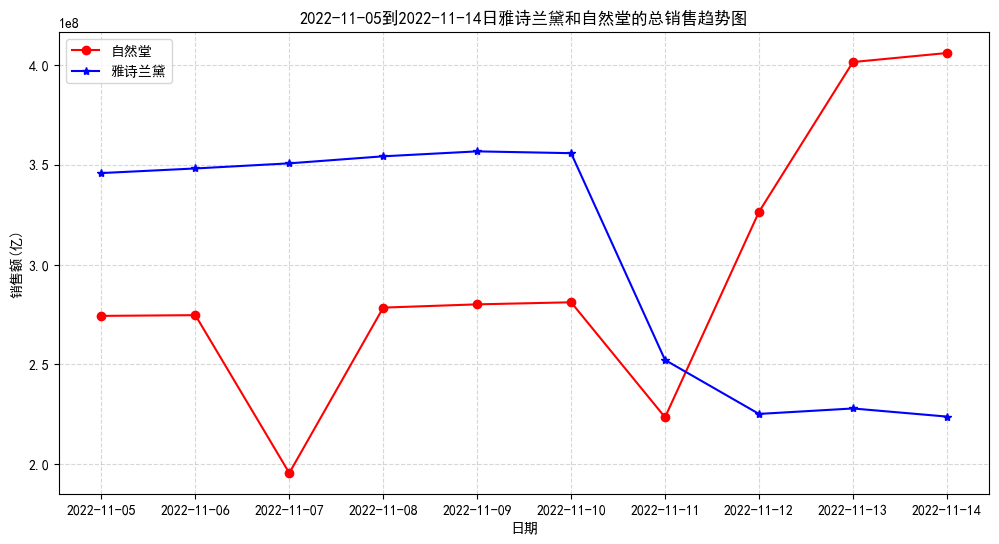

In [22]:
# ===== 品牌每日销售额趋势折线图 =====
# 双折线对比自然堂与雅诗兰黛在 11.05-11.14 的销售额走势
plt.figure(figsize=(12,6))
plt.plot(taobao_05_14_groupby_zrt['update_time'],taobao_05_14_groupby_zrt['销售额'],color='r',marker='o',label='自然堂')
plt.plot(taobao_05_14_groupby_ysld['update_time'],taobao_05_14_groupby_ysld['销售额'],color='b',marker='*',label='雅诗兰黛')
plt.xlabel('日期')
plt.ylabel('销售额(亿)')
plt.title('2022-11-05到2022-11-14日雅诗兰黛和自然堂的总销售趋势图')
plt.grid(True,alpha=0.5,linestyle='--')
plt.legend()
plt.show()

In [23]:
# ===== 悦诗风吟分析（第三题）=====
# 筛选出悦诗风吟店铺的全部记录
#第三题
taobao_ysfy = taobao_data.query('店名 == "悦诗风吟"')
taobao_ysfy

,update_time,id,title,price,sale_count,comment_count,店名,销售额
2761,2022-11-14,A14113837522,innisfree/悦诗风吟绿茶精萃平衡柔肤水 保湿补水清爽滋润爽肤水,115.0,41886,5736.0,悦诗风吟,4816890.0
2762,2022-11-14,A14113994476,innisfree/悦诗风吟美白提亮柔肤水 爽肤水保湿滋润改善暗沉,140.0,8548,356.0,悦诗风吟,1196720.0
2763,2022-11-14,A14114054180,innisfree/悦诗风吟香榧舒缓调理水 爽肤水保湿,125.0,5983,691.0,悦诗风吟,747875.0
2764,2022-11-14,A14116625037,innisfree/悦诗风吟 生机展颜面霜80ml 紧致保湿补水淡化细纹韩国,250.0,141,31.0,悦诗风吟,35250.0
2765,2022-11-14,A14256553980,innisfree/悦诗风吟红酒磨砂ㄠ 补水保湿温和去角质,90.0,3370,316.0,悦诗风吟,303300.0
...,...,...,...,...,...,...,...,...
5777,2022-11-05,A538953208180,【预售】innisfree/悦诗风吟小清新之旅绿茶精萃护肤4件套 补水,135.0,2425,0.0,悦诗风吟,327375.0
5778,2022-11-05,A538993276571,innisfree/悦诗风吟 绿茶精萃保湿护手霜50ml 2只装,100.0,7,0.0,悦诗风吟,700.0
5779,2022-11-05,A539378514948,innisfree/悦诗风吟 济州岛海盐洁面乳（温和滋润）130ml,80.0,140,51.0,悦诗风吟,11200.0
5780,2022-11-05,A540638275835,innisfree/悦诗风吟 莹润调色气垫隔离霜限量版 水润保湿修饰隔离,236.0,0,0.0,悦诗风吟,0.0


In [24]:
# 按日期分组，分别汇总悦诗风吟的销售额与销量
taobao_ysfy_Total_Sales = taobao_ysfy.groupby('update_time')['销售额'].sum().reset_index()
taobao_ysfy_Total_sales = taobao_ysfy.groupby('update_time')['sale_count'].sum().reset_index()

In [25]:
# 查看每日总销量
taobao_ysfy_Total_sales

,update_time,sale_count
0,2022-11-05,3983286
1,2022-11-06,4003622
2,2022-11-07,4015237
3,2022-11-08,4021346
4,2022-11-09,4079415
5,2022-11-10,4098469
6,2022-11-11,3868726
7,2022-11-12,3665169
8,2022-11-13,3666842
9,2022-11-14,3668384


In [26]:
# 查看每日总销售额
taobao_ysfy_Total_Sales

,update_time,销售额
0,2022-11-05,346760379.0
1,2022-11-06,348999507.0
2,2022-11-07,350201902.0
3,2022-11-08,350699373.0
4,2022-11-09,358236328.0
5,2022-11-10,360323457.0
6,2022-11-11,322504847.0
7,2022-11-12,316385418.0
8,2022-11-13,316426453.0
9,2022-11-14,316424781.0


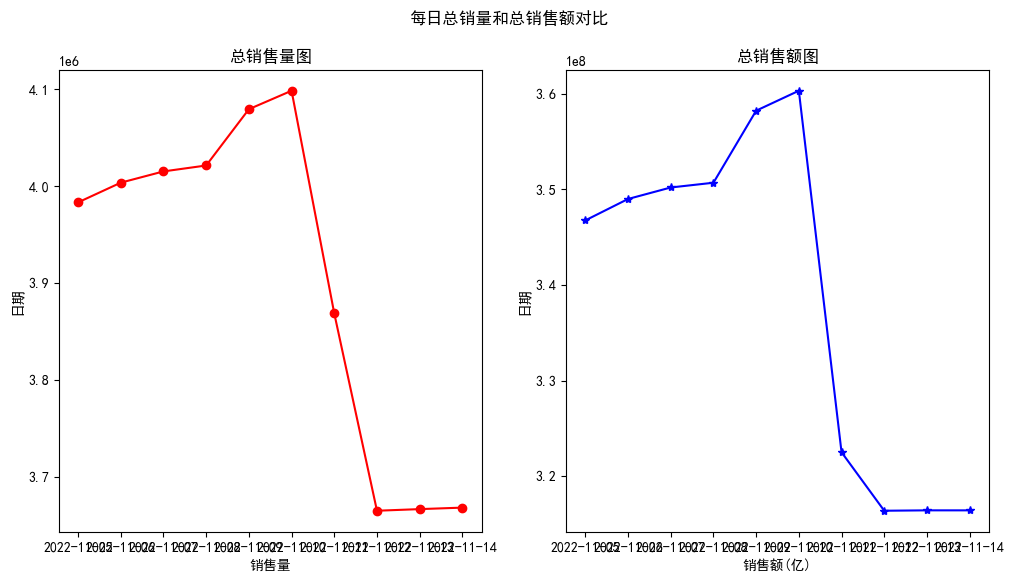

In [27]:
# ===== 悦诗风吟每日销量/销售额双图对比 =====
# 用 1 行 2 列子图，同时展示每日销量和每日销售额的变化趋势
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].plot(taobao_ysfy_Total_sales['update_time'],taobao_ysfy_Total_sales['sale_count'],color='r',marker='o',label='总销售量')
axes[0].set_ylabel('日期')
axes[0].set_xlabel('销售量')
axes[0].set_title('总销售量图')
axes[1].plot(taobao_ysfy_Total_Sales['update_time'],taobao_ysfy_Total_Sales['销售额'],color='b',marker='*',label='总销额')
axes[1].set_ylabel('日期')
axes[1].set_xlabel('销售额(亿)')
axes[1].set_title('总销售额图')
plt.suptitle('每日总销量和总销售额对比')
plt.show()

In [28]:
# 查看全表数据
#第四题
taobao_data

,update_time,id,title,price,sale_count,comment_count,店名,销售额
0,2022-11-14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719,2704.0,自然堂,3713941.0
1,2022-11-14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122,1492.0,自然堂,1575668.0
2,2022-11-14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668,589.0,自然堂,1254132.0
3,2022-11-14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805,4287.0,自然堂,980590.0
4,2022-11-14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196,618.0,自然堂,722244.0
...,...,...,...,...,...,...,...,...
27124,2022-11-05,A539946580915,佰草集惊艳时光十八周年典萃限量礼盒护肤套装 预售有礼,380.0,722,0.0,佰草集,274360.0
27125,2022-11-05,A539973230837,佰草集平衡洁面乳洗面奶100g*2支保湿补水控油 赠旅行套 预售有礼,96.0,3520,0.0,佰草集,337920.0
27126,2022-11-05,A540021300133,Herborist/佰草集新七白美白嫩肤面膜260g 补水保湿嫩肤,420.0,10738,5494.0,佰草集,4509960.0
27127,2022-11-05,A540084337255,Herborist/佰草集新美肌梦幻曲面膜组23片装,580.0,0,0.0,佰草集,0.0


In [29]:
# ===== 雅漾节前节后对比（第四题）=====
# 筛选雅漾在 11.05-11.14 的记录，按日期求平均销售额
# 取 11.11 当天的日期作为'双十一分界线'
taobao_data_yl_05and14 = taobao_data[(taobao_data['店名'] == '雅漾') & (taobao_data['update_time'] >= '2022-11-05') & (taobao_data['update_time'] <= '2022-11-14')]
taobao_data_yl_05and14_groupby = taobao_data_yl_05and14.groupby('update_time')['销售额'].mean().reset_index().astype({'销售额':'int'})
taobao_data_yl_05and14_groupby
Boundar_line = taobao_data_yl_05and14_groupby[(taobao_data_yl_05and14_groupby['update_time'] == '2022-11-11')]['update_time'].astype('str')
Boundar_line

6    2022-11-11
Name: update_time, dtype: str

NameError: name 'taobao_data_yl_05and11_groupby' is not defined

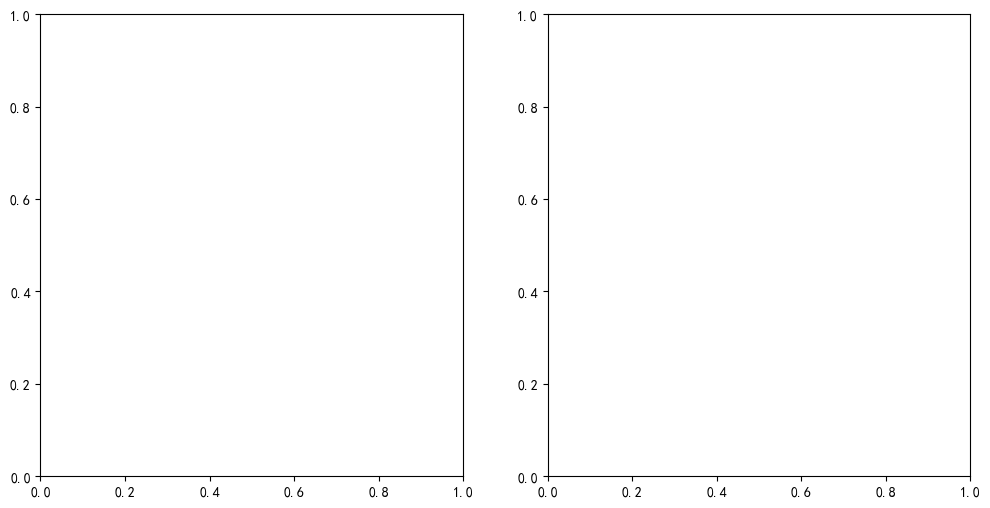

In [30]:
# ⚠️ 此 cell 引用了未定义的变量 taobao_data_yl_05and11_groupby / taobao_data_yl_12and14_groupby
# 运行会报 NameError，建议先按 cell[28] 的思路分别定义'节前(5-10日)'和'节后(12-14日)'两组数据再绘图
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].plot(taobao_data_yl_05and11_groupby['update_time'],
            taobao_data_yl_05and11_groupby['销售额'],
            color='r',
            marker='o')
axes[0].set_ylabel('销售额')
axes[0].set_xlabel('日期')
axes[0].set_title('节前(5-10日)销售额趋势')
axes[1].plot(taobao_data_yl_12and14_groupby['update_time'],
            taobao_data_yl_12and14_groupby['销售额'],
            color='b',
            marker='*')
axes[1].set_ylabel('销售额')
axes[1].set_xlabel('日期')
axes[1].set_title('节后(2-14日)销售额趋势')
plt.suptitle('节前（5-10日）和节后（12-14日）的平均销售额对比折线')
plt.show()

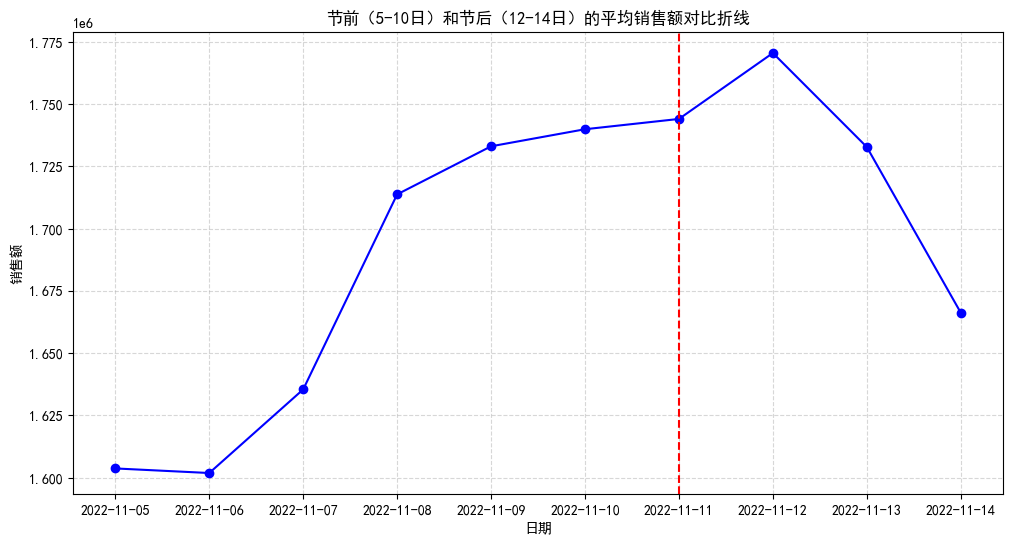

In [31]:
# 雅漾 11.05-11.14 平均销售额走势，红色虚线标记双十一当天（11.11）
plt.figure(figsize=(12,6))
plt.plot(taobao_data_yl_05and14_groupby['update_time'],
         taobao_data_yl_05and14_groupby['销售额'],
         color='b',
         marker='o')
plt.ylabel('销售额')
plt.xlabel('日期')
plt.title('节前（5-10日）和节后（12-14日）的平均销售额对比折线')
plt.grid(True,alpha=0.5,linestyle='--')
plt.axvline(x=Boundar_line,color='r',linestyle='--')
plt.show()

In [32]:
# ===== 双十一当天各店销售额 =====
# 筛选 11.11 当天的数据，按店名汇总销售额
taobao_data_bool = taobao_data[(taobao_data['update_time'] == '2022-11-11')]
taobao_data_bool_groupby = taobao_data_bool.groupby(['店名'])['销售额'].sum().reset_index().astype({'销售额':'int'})
taobao_data_bool_groupby

,店名,销售额
0,佰草集,266694468
1,倩碧,180991100
2,兰芝,255916907
3,兰蔻,132043955
4,妮维雅,202107051
5,娇兰,3252780
6,悦诗风吟,322504847
7,欧珀莱,96512970
8,欧莱雅,436572215
9,相宜本草,313098238


In [33]:
# 同时汇总整个 11.05-11.14 期间各店的总销售额，用于计算占比
taobao_data_bool2 = taobao_data[(taobao_data['update_time'] >= '2022-11-05') & (taobao_data['update_time'] <= '2022-11-14')]
taobao_data_bool2_groupby = taobao_data_bool2.groupby(['店名'])['销售额'].sum().reset_index().astype({'销售额':'int'})
taobao_data_bool2_groupby

,店名,销售额
0,佰草集,4018679349
1,倩碧,1999199220
2,兰芝,2525665625
3,兰蔻,1647341010
4,妮维雅,2200168404
5,娇兰,75601800
6,悦诗风吟,3386962445
7,欧珀莱,1119465071
8,欧莱雅,5312478542
9,相宜本草,6145791045


In [34]:
# 创建空 DataFrame 存放各店'销售额占比'
taobao_proportion = pd.DataFrame(columns=['店名','销售额占比'])

In [35]:
# 把'店名'列填入占比表
taobao_proportion['店名'] = taobao_data_bool2_groupby['店名']

In [36]:
# 计算占比：双十一当天销售额 / 活动期间总销售额
taobao_proportion['销售额占比'] = taobao_data_bool_groupby['销售额']/taobao_data_bool2_groupby['销售额']

In [37]:
# 查看销售额占比最高的 3 家店
taobao_proportion.nlargest(3,'销售额占比')

,店名,销售额占比
2,兰芝,0.101327
6,悦诗风吟,0.095219
4,妮维雅,0.091860


In [38]:
# ===== 三品牌对比 =====
# 筛选兰芝、悦诗风吟、妮维雅三家店的记录
taobao_data_sum1 = taobao_data.query('店名 == "兰芝" or 店名 == "悦诗风吟" or 店名 == "妮维雅"')
taobao_data_sum1

,update_time,id,title,price,sale_count,comment_count,店名,销售额
2761,2022-11-14,A14113837522,innisfree/悦诗风吟绿茶精萃平衡柔肤水 保湿补水清爽滋润爽肤水,115.0,41886,5736.0,悦诗风吟,4816890.0
2762,2022-11-14,A14113994476,innisfree/悦诗风吟美白提亮柔肤水 爽肤水保湿滋润改善暗沉,140.0,8548,356.0,悦诗风吟,1196720.0
2763,2022-11-14,A14114054180,innisfree/悦诗风吟香榧舒缓调理水 爽肤水保湿,125.0,5983,691.0,悦诗风吟,747875.0
2764,2022-11-14,A14116625037,innisfree/悦诗风吟 生机展颜面霜80ml 紧致保湿补水淡化细纹韩国,250.0,141,31.0,悦诗风吟,35250.0
2765,2022-11-14,A14256553980,innisfree/悦诗风吟红酒磨砂ㄠ 补水保湿温和去角质,90.0,3370,316.0,悦诗风吟,303300.0
...,...,...,...,...,...,...,...,...
22381,2022-11-05,A540802974360,【11.11专享】兰芝致美精华+致美眼霜套装 舒缓干燥 改善皱纹,825.0,0,0.0,兰芝,0.0
22382,2022-11-05,A540803415757,【11.11专享】兰芝致美水乳眼霜精华套装 紧致肌肤 官方正品,1465.0,0,0.0,兰芝,0.0
22383,2022-11-05,A540804667599,【11.11专享】兰芝水衡水乳面膜精华套装 补水保湿 滋润 官方正品,920.0,0,0.0,兰芝,0.0
22384,2022-11-05,A541112823938,【11.11特供】兰芝水衡水乳化妆品护肤套装 补水保湿 滋润,430.0,0,0.0,兰芝,0.0


In [39]:
# 按[日期, 店名]分组汇总销售额，再用 isin 保留目标三家店
taobao_data_sum1_groupby = taobao_data_sum1.groupby(['update_time','店名'])['销售额'].sum().reset_index()
brands = ['兰芝', '悦诗风吟', '妮维雅']
taobao_data_sum1_groupby_lz_ysfy_nwy = taobao_data_sum1_groupby[(taobao_data_sum1_groupby['店名'].isin(brands))]


In [40]:
# ⚠️ 此 cell 引用了未定义的变量 taobao_data_sum1_groupby_lz（兰芝单独分组）
# 运行会 NameError，需先按店名拆分为 lz/ysfy/nwy 三个变量
taobao_data_sum1_groupby_lz

NameError: name 'taobao_data_sum1_groupby_lz' is not defined

In [41]:
# ⚠️ 同上：taobao_data_sum1_groupby_lz / _ysfy / _nwy 均未定义，运行会报错
# 修复后可绘制三家店每日销售额对比折线图
plt.figure(figsize=(12,6))
plt.plot(taobao_data_sum1_groupby_lz['update_time'],
        taobao_data_sum1_groupby_lz['销售额'],
        color='b',
        label='兰芝')
plt.plot(taobao_data_sum1_groupby_ysfy['update_time'],
        taobao_data_sum1_groupby_ysfy['销售额'],
        color='r',
        label='悦诗风吟')
plt.plot(taobao_data_sum1_groupby_nwy['update_time'],
        taobao_data_sum1_groupby_nwy['销售额'],
        color='g',
        label='妮维雅')
plt.xlabel('日期')
plt.ylabel('销售额')
plt.title('销售占比最高的三家店的每日总销量趋势图')
plt.grid(True,alpha=0.6,linestyle='--')
plt.legend()
plt.show()

NameError: name 'taobao_data_sum1_groupby_lz' is not defined

<Figure size 1200x600 with 0 Axes>

In [42]:
# ===== 面膜销售额排名 =====
# ⚠️ 变量名不一致：上方定义的是 Face_mask_products_groupby_（带下划线）
# 此处使用 Face_mask_products_groupby（无下划线），运行会 NameError
Face_mask_products = taobao_data[(taobao_data['title'].str.contains('面膜'))]
Face_mask_products_groupby_ = Face_mask_products.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})
Face_mask_products_groupby.sort_values('销售额',ascending=False)

NameError: name 'Face_mask_products_groupby' is not defined

In [43]:
# 筛选佰草集的面膜商品，按[日期, 商品名]汇总销售额
Face_mask_products_wbj = Face_mask_products.query('店名 == "佰草集"')
Face_mask_products_wbj_grouoby = Face_mask_products_wbj.groupby(['update_time','title'])['销售额'].sum().reset_index()
Face_mask_products_wbj_grouoby

,update_time,title,销售额
0,2022-11-05,Herborist/佰草集 新恒美紧肤水晶面膜120g,63000.0
1,2022-11-05,Herborist/佰草集·典萃水润活颜水晶面膜120ml保湿补水,46800.0
2,2022-11-05,Herborist/佰草集·典萃玉肌亮颜按摩面膜120g提亮肤色,12320.0
3,2022-11-05,Herborist/佰草集全天候焕肤保湿面膜120ml,53640.0
4,2022-11-05,Herborist/佰草集悦风舒润柔肤面膜5片装,16000.0
...,...,...,...
271,2022-11-14,Herborist/佰草集薏苡莹润·薏仁面膜7片装,65280.0
272,2022-11-14,Herborist/佰草集逆时修护·雪莲面膜7片装,105120.0
273,2022-11-14,佰草集新七白美白嫩肤面膜M260g中号保湿补水,1922600.0
274,2022-11-14,佰草集新玉润保湿水晶面膜120ml 免洗睡眠型滋润补水 旗舰店正品,3887460.0


In [44]:
# 佰草集面膜按日期汇总总销售额
Face_mask_products_wbj_grouoby2 = Face_mask_products_wbj_grouoby.groupby('update_time')['销售额'].sum().reset_index()
Face_mask_products_wbj_grouoby2

,update_time,销售额
0,2022-11-05,105878914.0
1,2022-11-06,106259979.0
2,2022-11-07,106622546.0
3,2022-11-08,107057195.0
4,2022-11-09,107453836.0
5,2022-11-10,107981627.0
6,2022-11-11,51067413.0
7,2022-11-12,105226078.0
8,2022-11-13,104534400.0
9,2022-11-14,104015825.0


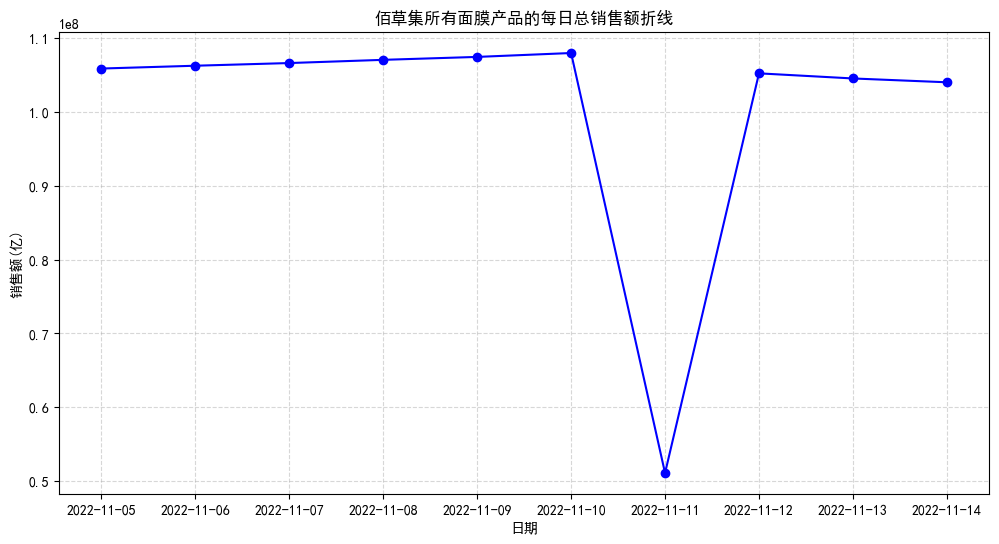

In [45]:
# 佰草集面膜每日总销售额折线图
plt.figure(figsize=(12,6))
plt.plot(Face_mask_products_wbj_grouoby2['update_time'],
        Face_mask_products_wbj_grouoby2['销售额'],
        color='b',
        marker='o')
plt.xlabel('日期')
plt.ylabel('销售额(亿)')
plt.title('佰草集所有面膜产品的每日总销售额折线')
plt.grid(True,alpha=0.5,linestyle='--')
plt.show()

In [46]:
# ===== 资生堂分析 =====
# ⚠️ 变量名错误：定义的是 zst_Daily_total_salessadasdasdasdasdas（拼写错误）
# 下面使用的 zst_Daily_total_sales 未定义，运行会 NameError
taobao_data_zst = taobao_data.query('店名 =="资生堂"')
zst_Daily_total_salessadasdasdasdasdas = taobao_data_zst.groupby('update_time')['销售额'].sum().reset_index().astype({'销售额':'int'})
zst_Total_reviews_per_day = taobao_data_zst.groupby('update_time')['comment_count'].sum().reset_index().astype({'comment_count':'int'})
zst_Daily_total_sales

NameError: name 'zst_Daily_total_sales' is not defined

NameError: name 'zst_Daily_total_sales' is not defined

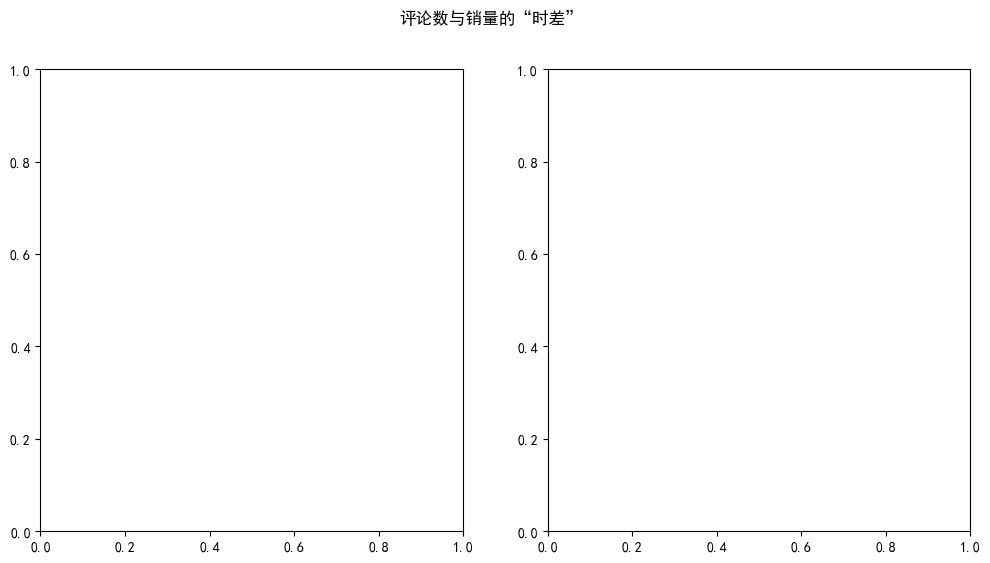

In [47]:
# ⚠️ 同上：zst_Daily_total_sales 未定义（正确变量名是 zst_Daily_total_salessadasdasdasdasdas）
# 修复后此图用于对比资生堂'销售额'与'评论数'的时间走势（观察评论滞后效应）
fig,axes = plt.subplots(1,2,figsize=(12,6))
plt.suptitle('评论数与销量的“时差”')
axes[0].plot(zst_Daily_total_sales['update_time'],
            zst_Daily_total_sales['销售额'],
            color='r',
            marker='o')
axes[0].set_xlabel('日期')
axes[0].set_ylabel('销售额(亿)')
axes[0].set_title('每日总销售额趋势')
axes[1].plot(zst_Total_reviews_per_day['update_time'],
            zst_Total_reviews_per_day['comment_count'],
            color='b',
            marker='*')
axes[1].set_xlabel('日期')
axes[1].set_ylabel('评论数量')
axes[1].set_title('每日总评论数量趋势')
plt.show()

In [48]:
# 查看资生堂每日评论数
zst_Total_reviews_per_day

,update_time,comment_count
0,2022-11-05,4617
1,2022-11-06,4468
2,2022-11-07,4235
3,2022-11-08,5074
4,2022-11-09,5556
5,2022-11-10,6056
6,2022-11-11,2319
7,2022-11-12,4064
8,2022-11-13,2023
9,2022-11-14,1759


In [49]:
# ===== 双十一当天各店销售额排序 =====
# 筛选 11.11 数据，按店名汇总销售额并降序排列
double_11 = taobao_data[(taobao_data['update_time'] == '2022-11-11')]
sales_by_int = double_11.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})
sort_container = sales_by_int.sort_values('销售额',ascending=False)

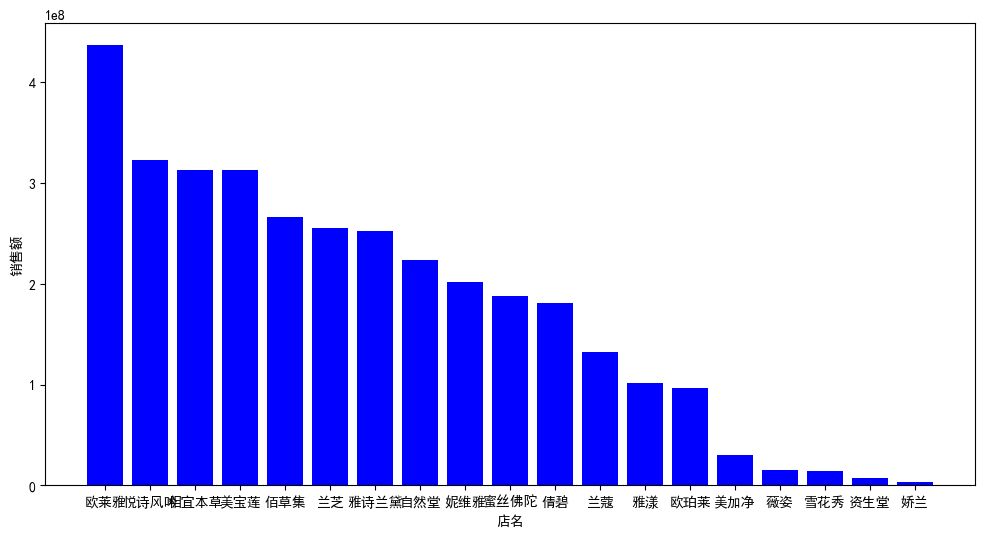

In [50]:
# 双十一当天各店销售额柱状图
plt.figure(figsize=(12,6))
plt.bar(sort_container['店名'],
       sort_container['销售额'],
       color='b')
plt.xlabel('店名')
plt.ylabel('销售额')
plt.show()

In [51]:
# ===== 品牌总销售额 =====
# 按店名汇总整个期间的总销售额，重命名为 brand_total_sales
brand_total = taobao_data.groupby('店名')['销售额'].sum().reset_index()
brand_total.rename(columns={'销售额': 'brand_total_sales'}, inplace=True)

In [52]:
# ===== 单品销售额占比分析 =====
# 按[店名, 商品名]分组计算单品销售额
# 取每个品牌销售额最高的单品，计算其占品牌总销售额的比例（集中度分析）
# 按品牌 + 单品分组，计算每个单品的总销售额
product_sales = taobao_data.groupby(['店名', 'title'])['销售额'].sum().reset_index()

# 找出每个品牌下销售额最高的那个单品（取第一行）
top1_per_brand = product_sales.sort_values(['店名', '销售额'], ascending=[True, False]) .groupby('店名').head(1) .reset_index(drop=True)

top1_per_brand.rename(columns={'销售额': 'top1_sales'}, inplace=True)
brand_with_top1 = top1_per_brand.merge(brand_total, on='店名', how='left')

# 计算占比
brand_with_top1['ratio'] = brand_with_top1['top1_sales'] / brand_with_top1['brand_total_sales']

# 看一眼结果
brand_with_top1[['店名', 'title', 'ratio']].sort_values('ratio', ascending=False)

,店名,title,ratio
4,妮维雅,德国妮维雅男士洗面奶控油祛痘印保湿去黑头去油清洁面乳液护肤品,0.312038
14,蜜丝佛陀,蜜丝佛陀水漾触感粉底霜液膏 遮瑕控油保湿强 彩妆专柜正品,0.308939
5,娇兰,【娇兰预售】guerlain亲亲唇膏口红套装 杨洋色344经典 滋润保湿,0.199094
6,悦诗风吟,innisfree/悦诗风吟绿茶水乳套装 补水保湿控油护肤品韩国化妆品,0.197531
12,自然堂,CHANDO/自然堂水润保湿面部护理套装 洗面奶爽肤水乳液面霜补水女,0.162854
18,雪花秀,雪花秀润致焕活肌底精华露90ml 润燥精华 保湿补水 润泽滋养,0.161392
13,薇姿,【特供套装】薇姿温泉护肤套装（水活霜+爽肤水）补水保湿,0.160873
16,雅漾,雅漾 舒护活泉水喷雾300ml 大喷保湿套装 爽肤水化妆水 秋冬补水,0.132408
0,佰草集,佰草集 新玉润深层补水套装补水保湿化妆品套装 补水套装,0.120723
2,兰芝,【11.11专享】兰芝气垫BB霜（美白）赠替换芯 遮瑕保湿 买1享8,0.118981


In [53]:
# 查看品牌总销售额
brand_total

,店名,brand_total_sales
0,佰草集,4.018679e+09
1,倩碧,1.999199e+09
2,兰芝,2.525666e+09
3,兰蔻,1.647341e+09
4,妮维雅,2.200168e+09
5,娇兰,7.560180e+07
6,悦诗风吟,3.386962e+09
7,欧珀莱,1.119465e+09
8,欧莱雅,5.312479e+09
9,相宜本草,6.145791e+09


In [54]:
# 查看每个品牌的销量冠军单品
top1_per_brand

,店名,title,top1_sales
0,佰草集,佰草集 新玉润深层补水套装补水保湿化妆品套装 补水套装,485145936.0
1,倩碧,Clinique倩碧 经典三步曲 1.0/1/2/3/4号 护肤套装,62745620.0
2,兰芝,【11.11专享】兰芝气垫BB霜（美白）赠替换芯 遮瑕保湿 买1享8,300505075.0
3,兰蔻,【11-11预售】兰蔻「小黑瓶」30ml 精华肌底液 精华深入肌底,184628320.0
4,妮维雅,德国妮维雅男士洗面奶控油祛痘印保湿去黑头去油清洁面乳液护肤品,686536297.5
5,娇兰,【娇兰预售】guerlain亲亲唇膏口红套装 杨洋色344经典 滋润保湿,15051840.0
6,悦诗风吟,innisfree/悦诗风吟绿茶水乳套装 补水保湿控油护肤品韩国化妆品,669028830.0
7,欧珀莱,AUPRES/欧珀莱时光锁紧致面部护理护肤套装女补水保湿化妆品,127529680.0
8,欧莱雅,【双11】L'OREAL欧莱雅复颜抗皱紧致套装 洁面面霜柔肤水三件套,263590950.0
9,相宜本草,【双11来啦】相宜本草红石榴护肤化妆品套装女美白补水乳保湿,567146620.0


In [55]:
# ===== 品类节前节后对比 =====
# 筛选商品名含'水乳/面膜/洁面/防晒'的品类
# 分别提取节前(11.05-11.10)与节后(11.12-11.14)两个时间段
match_title = '水乳|面膜|洁面|防晒'
fuzzy_matching = taobao_data[(taobao_data['title'].str.contains(match_title,na=False))]
selected_time_period1 = fuzzy_matching[(fuzzy_matching['update_time'] >= '2022-11-05') & (fuzzy_matching['update_time'] <= '2022-11-10')]
selected_time_period2 = fuzzy_matching[(fuzzy_matching['update_time'] >= '2022-11-12') & (fuzzy_matching['update_time'] <= '2022-11-14')]

In [56]:
# 分别汇总节前、节后各店品类销售额
total_sales1 = selected_time_period1.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})
total_sales2 = selected_time_period2.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})

In [57]:
# merge：按店名拼接节前/节后销售额，后缀区分两个时期
total_sales_merge = pd.merge(total_sales1,total_sales2,on='店名',suffixes=('_before', '_after'))

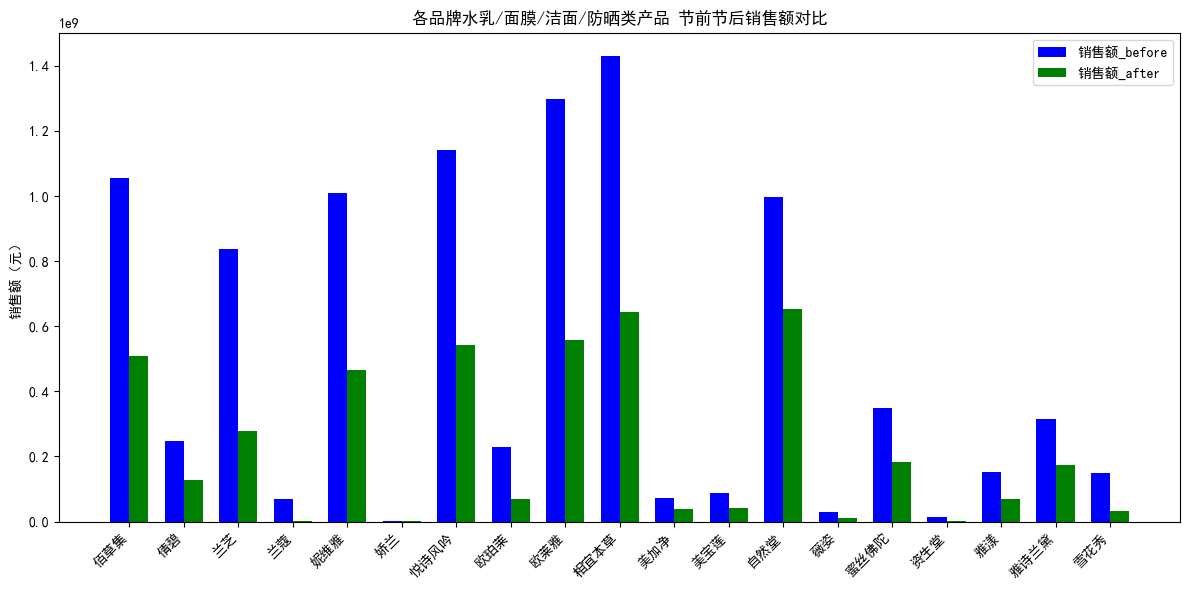

In [58]:
# 分组柱状图对比各品牌品类商品节前节后销售额
plt.figure(figsize=(12,6))
x = range(len(total_sales_merge))
width = 0.35
plt.bar([i-width/2 for i in x],total_sales_merge['销售额_before'],color='b',width=width,label='销售额_before')
plt.bar([i+width/2 for i in x],total_sales_merge['销售额_after'],color='g',width=width,label='销售额_after')
plt.legend()
plt.xticks(x, total_sales_merge['店名'], rotation=45, ha='right')
plt.ylabel('销售额（元）')
plt.title('各品牌水乳/面膜/洁面/防晒类产品 节前节后销售额对比')
plt.tight_layout()
plt.show()

In [59]:
# 查看拼接后的对比表
total_sales_merge

,店名,销售额_before,销售额_after
0,佰草集,1055749292,509070933
1,倩碧,248626000,128311740
2,兰芝,838113171,277130947
3,兰蔻,69058580,771620
4,妮维雅,1008257423,465643296
5,娇兰,453400,275290
6,悦诗风吟,1141846236,541368881
7,欧珀莱,229714595,68825600
8,欧莱雅,1298319804,557440294
9,相宜本草,1430603016,643982663


In [60]:
# ===== 价格档划分 =====
# pd.cut：将价格划分为三档（100 以下 / 100-300 / 300 以上）
taobao_data['价格档'] = pd.cut(taobao_data['price'],
                            bins=[-float('inf'),100,300,float('inf')],
                           labels=['100元以下','100-300元','300元以上'],
                           right=False)

In [61]:
# 按价格档汇总销售额并降序排列
price_sales = taobao_data.groupby('价格档')['销售额'].sum().reset_index().astype({'销售额':'int'}).sort_values('销售额',ascending=False)
price_sales

,价格档,销售额
1,100-300元,19534527861
2,300元以上,13315576674
0,100元以下,9435038891


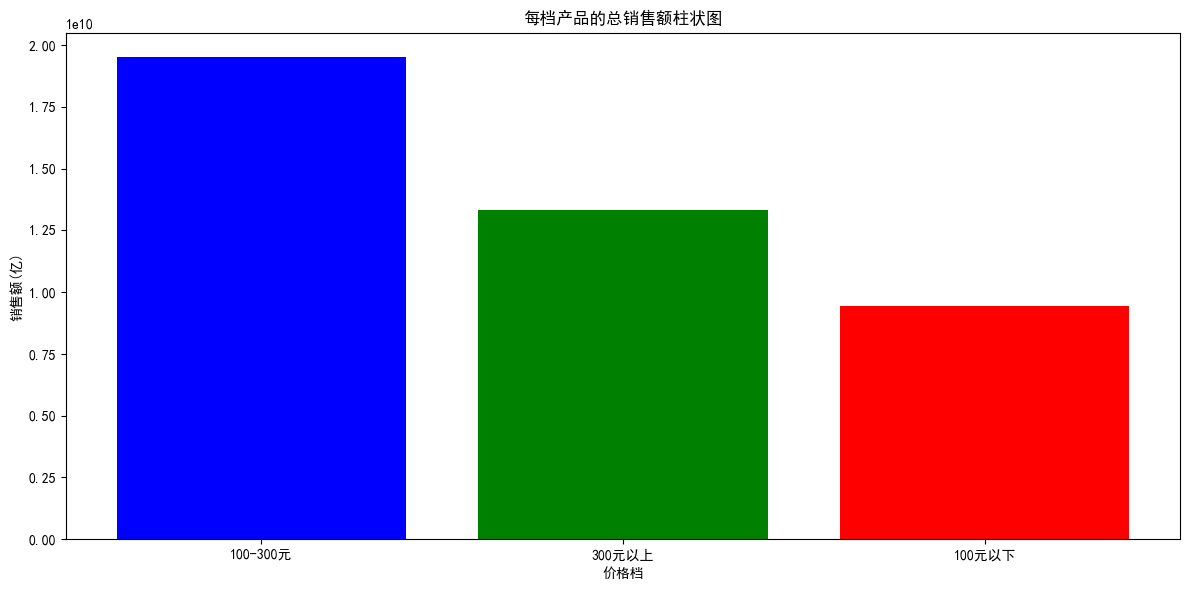

In [62]:
# 价格档销售额柱状图
colors = ['b','g','r']
plt.figure(figsize=(12,6))
plt.bar(price_sales['价格档'],
       price_sales['销售额'],
       color=colors)
plt.xlabel('价格档')
plt.ylabel('销售额(亿)')
plt.title('每档产品的总销售额柱状图')
plt.tight_layout()
plt.show()

In [63]:
# ===== 节日中 vs 节日后对比 =====
# 分别取双十一当天(11.11)和节后(11.12-11.13)的数据，按店名汇总销售额
Holiday_11 = taobao_data[(taobao_data['update_time'] == '2022-11-11')]
After_the_holiday = taobao_data[(taobao_data['update_time'] >= '2022-11-12') & (taobao_data['update_time'] <= '2022-11-13')]
Holiday_11_gropby = Holiday_11.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})
After_the_holiday_groupby = After_the_holiday.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})

In [64]:
# 查看双十一当天各店销售额
Holiday_11_gropby

,店名,销售额
0,佰草集,266694468
1,倩碧,180991100
2,兰芝,255916907
3,兰蔻,132043955
4,妮维雅,202107051
5,娇兰,3252780
6,悦诗风吟,322504847
7,欧珀莱,96512970
8,欧莱雅,436572215
9,相宜本草,313098238


In [65]:
# 查看节后各店销售额
After_the_holiday_groupby

,店名,销售额
0,佰草集,868958196
1,倩碧,373599040
2,兰芝,403546155
3,兰蔻,3884860
4,妮维雅,396552811
5,娇兰,14052195
6,悦诗风吟,632811871
7,欧珀莱,167162021
8,欧莱雅,998230976
9,相宜本草,990572038


In [66]:
# merge 拼接两个时期，后缀区分'节日中/节日后'
Comparison = pd.merge(Holiday_11_gropby,After_the_holiday_groupby,on='店名',suffixes=('_节日中','_节日后'))
Comparison

,店名,销售额_节日中,销售额_节日后
0,佰草集,266694468,868958196
1,倩碧,180991100,373599040
2,兰芝,255916907,403546155
3,兰蔻,132043955,3884860
4,妮维雅,202107051,396552811
5,娇兰,3252780,14052195
6,悦诗风吟,322504847,632811871
7,欧珀莱,96512970,167162021
8,欧莱雅,436572215,998230976
9,相宜本草,313098238,990572038


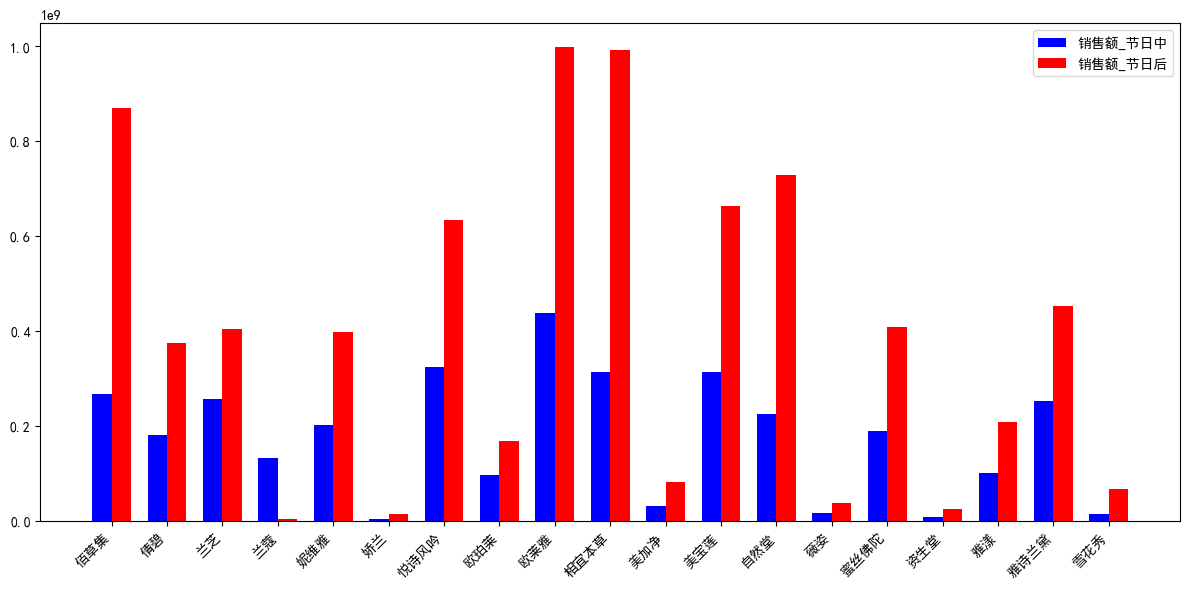

In [67]:
# 分组柱状图：对比双十一当天与节后的销售额变化（观察大促透支效应）
plt.figure(figsize=(12,6))
x = range(len(Comparison))
width = 0.35
plt.bar([i-width/2 for i in x],Comparison['销售额_节日中'],color='b',width=width,label='销售额_节日中')
plt.bar([i+width/2 for i in x],Comparison['销售额_节日后'],color='r',width=width,label='销售额_节日后')
plt.legend()
plt.xticks(x,Comparison['店名'],rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [68]:
# ===== 折扣率分析 =====
# 取双十一当天各商品的 id 与价格，与 11 月 5 日价格对比计算折扣率
# ⚠️ 注意：'2022-11-5' 与 '2022-11-05' 格式不一致，可能导致匹配不到数据
Holiday_Day_Price = taobao_data[(taobao_data['update_time'] == '2022-11-11')][['id','店名','price']]
Original_price = taobao_data[(taobao_data['update_time'] == '2022-11-5')][['id','price']]
discount_rate = pd.merge(Holiday_Day_Price,Original_price,on='id',suffixes=('_节日中的价格','_节日后的价格'))
discount_rate['折扣率'] = discount_rate['price_节日中的价格']/discount_rate['price_节日后的价格']
discount_rate_groupby = discount_rate.groupby('店名')['折扣率'].mean().reset_index().sort_values('折扣率')
discount_rate_groupby

,店名,折扣率
9,相宜本草,0.540816
0,佰草集,0.584057
12,自然堂,0.708102
14,蜜丝佛陀,0.823203
11,美宝莲,0.865652
10,美加净,0.917368
4,妮维雅,0.926051
8,欧莱雅,0.957298
13,薇姿,0.965161
7,欧珀莱,0.969625


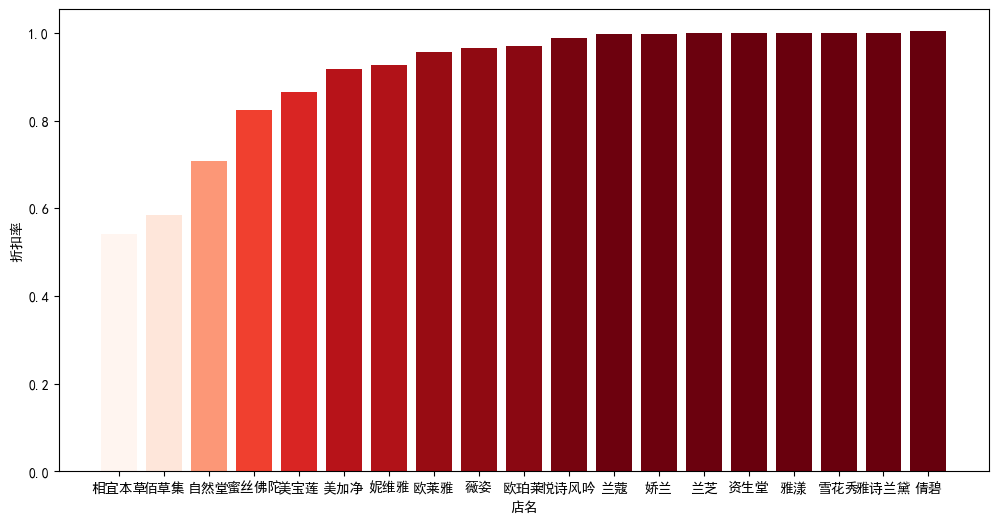

In [69]:
# 各店平均折扣率柱状图（颜色深浅表示折扣力度）
plt.figure(figsize=(12,6))
norm = plt.Normalize(vmin = discount_rate_groupby['折扣率'].min(),vmax=discount_rate_groupby['折扣率'].max())
colors = plt.cm.Reds(norm(discount_rate_groupby['折扣率']))
plt.bar(discount_rate_groupby['店名'],
       discount_rate_groupby['折扣率'],
       color = colors)
plt.xlabel('店名')
plt.ylabel('折扣率')
plt.show()

In [70]:
# ===== 单品销售额 Top10 =====
# 按商品名汇总销售额，取前 10
top_10 = taobao_data.groupby('title')['销售额'].sum().reset_index().nlargest(10,'销售额')
top_10

,title,销售额
3145,德国妮维雅男士洗面奶控油祛痘印保湿去黑头去油清洁面乳液护肤品,686536297.5
1018,innisfree/悦诗风吟绿茶水乳套装 补水保湿控油护肤品韩国化妆品,669028830.0
3680,蜜丝佛陀水漾触感粉底霜液膏 遮瑕控油保湿强 彩妆专柜正品,643355951.2
2065,【双11来啦】相宜本草红石榴护肤化妆品套装女美白补水乳保湿,567146620.0
3694,蜜丝佛陀透滑粉饼 干湿两用遮瑕控油防晒定妆 彩妆专柜正品,519041946.6
2713,佰草集 新玉润深层补水套装补水保湿化妆品套装 补水套装,485145936.0
160,CHANDO/自然堂水润保湿面部护理套装 洗面奶爽肤水乳液面霜补水女,478979562.0
400,Herborist/佰草集新七白嫩肤面膜泥补水保湿修护白皙肌肤,315232600.0
196,CHANDO/自然堂雪域精粹纯粹冰肌滋润套装 洗面奶爽肤水乳液面霜,313220560.0
193,CHANDO/自然堂雪域精粹水乳套装 爽肤水冰肌水乳液面霜护理套装,307128970.0


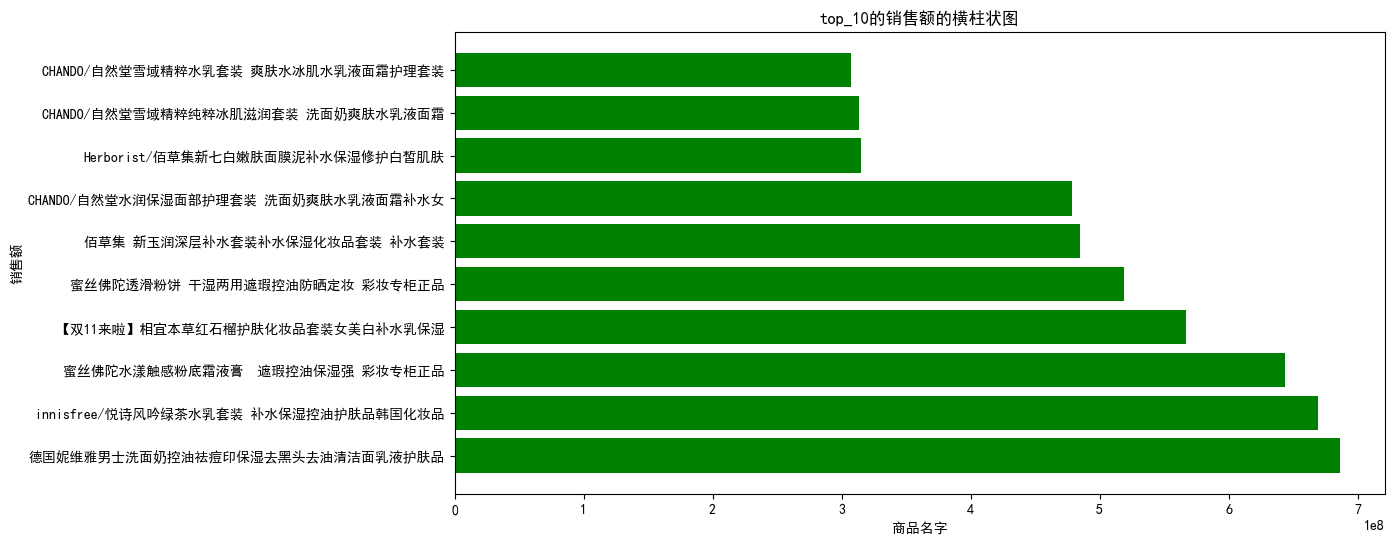

In [71]:
# Top10 商品横向柱状图
plt.figure(figsize=(12,6))
plt.barh(top_10['title'],top_10['销售额'],color='g')
plt.xlabel('商品名字')
plt.ylabel('销售额')
plt.title('top_10的销售额的横柱状图')
plt.show()

In [81]:
# ===== 面膜销售占比 =====
# 分别汇总自然堂/雅诗兰黛/悦诗风吟的总销售额与面膜销售额
Selected_Brand = taobao_data.query('店名 == "自然堂" or 店名 == "雅诗兰黛" or 店名 == "悦诗风吟"')
Selected_Brand_Facemask = Selected_Brand[(Selected_Brand['title'].str.contains('面膜'))]
Selected_Brand_groupby = Selected_Brand.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})
Selected_Brand_Facemask_groupby = Selected_Brand_Facemask.groupby('店名')['销售额'].sum().reset_index().astype({'销售额':'int'})
Sales_share = pd.merge(Selected_Brand_groupby,Selected_Brand_Facemask_groupby,on='店名',suffixes=('_总销售额','_面膜销售额'))

In [82]:
# 查看三家店的面膜销售额
Selected_Brand_Facemask_groupby

,店名,销售额
0,悦诗风吟,573760620
1,自然堂,250277946
2,雅诗兰黛,88627820


In [83]:
# 查看三家店的总销售额
Selected_Brand_groupby

,店名,销售额
0,悦诗风吟,3386962445
1,自然堂,2941153447
2,雅诗兰黛,3040251794


In [84]:
# 查看合并后的对比表
Sales_share

,店名,销售额_总销售额,销售额_面膜销售额
0,悦诗风吟,3386962445,573760620
1,自然堂,2941153447,250277946
2,雅诗兰黛,3040251794,88627820


In [86]:
# 计算差值 = 总销售额 - 面膜销售额（即非面膜品类的销售额）
Sales_share['差值'] = Sales_share['销售额_总销售额'] - Sales_share['销售额_面膜销售额']
Sales_share

,店名,销售额_总销售额,销售额_面膜销售额,差值
0,悦诗风吟,3386962445,573760620,2813201825
1,自然堂,2941153447,250277946,2690875501
2,雅诗兰黛,3040251794,88627820,2951623974


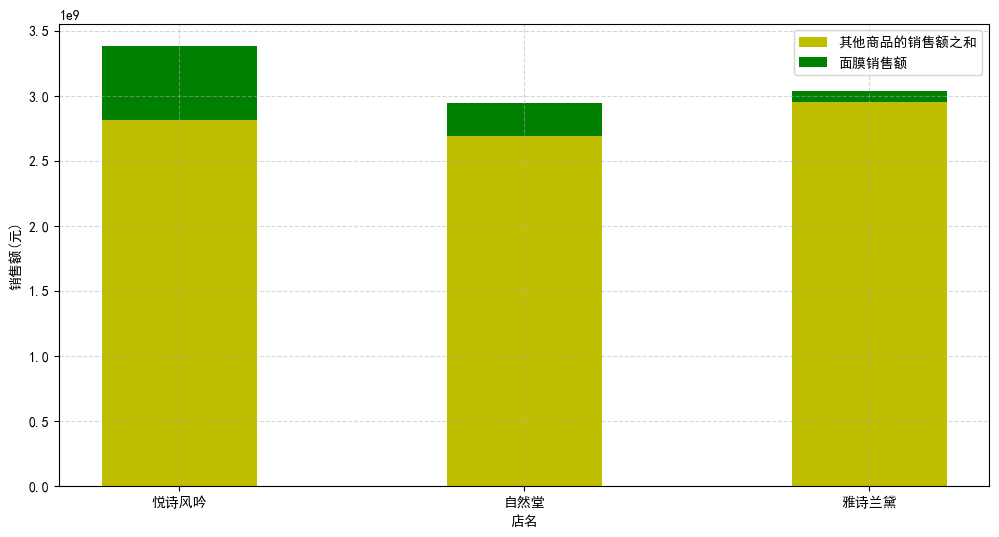

In [89]:
# 堆叠柱状图：绿色为面膜销售额，黄色为其他品类，直观展示面膜占比
plt.figure(figsize=(12,6))
plt.bar(Sales_share['店名'],Sales_share['差值'],color='y',label='其他商品的销售额之和',width=0.45)
plt.bar(Sales_share['店名'],Sales_share['销售额_面膜销售额'],bottom=Sales_share['差值'],color='g',label='面膜销售额',width=0.45)
plt.xlabel('店名')
plt.ylabel('销售额(元)')
plt.grid(True,alpha=0.5,linestyle='--')
plt.legend()
plt.show()

In [90]:
# 查看全表
taobao_data

,update_time,id,title,price,sale_count,comment_count,店名,销售额,价格档
0,2022-11-14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719,2704.0,自然堂,3713941.0,100-300元
1,2022-11-14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122,1492.0,自然堂,1575668.0,100-300元
2,2022-11-14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668,589.0,自然堂,1254132.0,100元以下
3,2022-11-14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805,4287.0,自然堂,980590.0,100元以下
4,2022-11-14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196,618.0,自然堂,722244.0,100-300元
...,...,...,...,...,...,...,...,...,...
27124,2022-11-05,A539946580915,佰草集惊艳时光十八周年典萃限量礼盒护肤套装 预售有礼,380.0,722,0.0,佰草集,274360.0,300元以上
27125,2022-11-05,A539973230837,佰草集平衡洁面乳洗面奶100g*2支保湿补水控油 赠旅行套 预售有礼,96.0,3520,0.0,佰草集,337920.0,100元以下
27126,2022-11-05,A540021300133,Herborist/佰草集新七白美白嫩肤面膜260g 补水保湿嫩肤,420.0,10738,5494.0,佰草集,4509960.0,300元以上
27127,2022-11-05,A540084337255,Herborist/佰草集新美肌梦幻曲面膜组23片装,580.0,0,0.0,佰草集,0.0,300元以上


In [114]:
# ===== 价格档与销量关系 =====
# 重新划分为四档（50 以下/50-150/150-500/500 以上），按价格档汇总销量
taobao_data['价格档'] = pd.cut(taobao_data['price'],
                            bins=[-float('inf'),50,150,500,float('inf')],
                           labels=['50元一下','50-150元','150-500','500以上'])
Price_Segmentation = taobao_data.groupby('价格档')['sale_count'].sum().reset_index().sort_values('sale_count')
Price_Segmentation

,价格档,sale_count
3,500以上,8685534
2,150-500,84841099
0,50元一下,88166739
1,50-150元,128203250


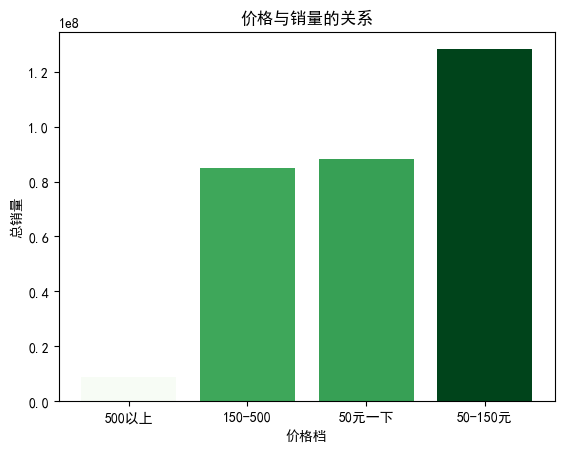

In [116]:
# 价格档销量柱状图（颜色深浅表示销量高低）
norm = plt.Normalize(vmin=Price_Segmentation['sale_count'].min(),vmax=Price_Segmentation['sale_count'].max())
colors= plt.cm.Greens(norm(Price_Segmentation['sale_count']))
plt.bar(Price_Segmentation['价格档'],Price_Segmentation['sale_count'],color=colors)
plt.xlabel('价格档')
plt.ylabel('总销量')
plt.title('价格与销量的关系')
plt.show()

In [119]:
# ===== 商品日销量环比 =====
# 按[日期, 商品名]分组汇总每日销量
Product_Grouping = taobao_data.groupby(['update_time','title'],as_index=False)['sale_count'].sum()
Product_Grouping

,update_time,title,sale_count
0,2022-11-05,2件*德国妮维雅唇膏男女润唇膏唇膜保湿滋润补水淡化唇纹护唇包邮,81
1,2022-11-05,2件*德国妮维雅唇膏男女润唇膏唇膜滋润保湿补水淡化唇纹无色包邮,887
2,2022-11-05,2件包邮*德国妮维雅男女士润唇膏修护唇膜口红保湿滋润补水有无色,8132
3,2022-11-05,2件包邮*德国妮维雅盈润丝柔保湿乳全身体乳护理滋润补水润体乳液,5114
4,2022-11-05,2件包邮】妮维雅盈润丝柔护手凝露护手霜手膜保湿补水男女润手霜,3942
...,...,...,...
25050,2022-11-14,雪花秀顺行柔和洁颜油200ml 卸妆油正品脸部眼唇 温和卸妆 不油腻,502
25051,2022-11-14,高性价比蜜丝佛陀粉嫩持妆粉底液保湿遮瑕控油 正品包邮,75181
25052,2022-11-14,鲜鲜水相宜本草山茶花焕活净颜乳温和洗面奶女,4847
25053,2022-11-14,鲜鲜水相宜本草山茶花焕活化妆品滋润保湿补水,2673


In [129]:
# shift(1)：取每个商品前一日的销量，计算当日环比差值（diff）
# 用于识别销量突降的商品
Product_Grouping['prev_sales'] = Product_Grouping.groupby('title')['sale_count'].shift(1)
Product_Grouping['diff'] = Product_Grouping['sale_count'] - Product_Grouping['prev_sales']
Product_Grouping.dropna(inplace=True)

In [137]:
# 筛选销量环比下降的记录，取下降幅度最大的 5 条
diff_boll = Product_Grouping[(Product_Grouping['diff'] < 0)]
diff_boll_nsmallest = diff_boll.nsmallest(5,'diff')
diff_boll_nsmallest

,update_time,title,sale_count,prev_sales,diff
7178,2022-11-07,【双11】L'OREAL欧莱雅奇焕光彩粉嫩透亮修颜霜SPF21 PA+++ bb霜,0,71769.0,-71769.0
7147,2022-11-07,【保湿】德国妮维雅男士水活精华洁面液洗面奶祛痘印保湿控油清爽,109,32253.0,-32144.0
7379,2022-11-07,【控油】德国妮维雅男士深层净油精华提亮肤色洁面炭泥洗面奶温和,34,23057.0,-23023.0
4124,2022-11-06,【11.11专享】Clinique倩碧 小雏菊胭脂腮红,7,20028.0,-20021.0
20475,2022-11-12,兰蔻 「小黑瓶」全规格精华肌底液 面部精华直达肌底补水保湿弹润,251,15183.0,-14932.0
